In [ ]:
import torch 
import pandas as pd 
import numpy 
import matplotlib.pyplot as plt 
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import os 
from PIL import Image
import random
import torch.nn as nn
from torchvision import models
from sklearn.metrics import roc_auc_score, recall_score, f1_score, confusion_matrix
import cv2
from pytorch_grad_cam import HiResCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

In [2]:
data_dir_train=r"C:\Users\Admin\Desktop\Alzhiemers\Alzhiemer - MRI Scan\train"

data_dir_test=r"C:\Users\Admin\Desktop\Alzhiemers\Alzhiemer - MRI Scan\test"

In [3]:
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [4]:
train_datasets=datasets.ImageFolder(root=data_dir_train,transform=data_transforms)
test_datasets=datasets.ImageFolder(root=data_dir_test,transform=data_transforms)


In [5]:
train_loader=DataLoader(train_datasets,shuffle=True,batch_size=32)
test_loader=DataLoader(test_datasets,batch_size=32)

In [7]:
import os

data_path = r"C:\Users\Admin\Desktop\Alzhiemers\Alzhiemer - MRI Scan\train"
total_images = 0

# 1. Loop through each subfolder (class)
for folder_name in os.listdir(data_path):
    # 2. Create the full path to the subfolder
    folder_path = os.path.join(data_path, folder_name)
    
    # 3. Check if it's actually a directory
    if os.path.isdir(folder_path):
        # 4. List all files and filter by extension
        images = [f for f in os.listdir(folder_path) if f.lower().endswith(('jpg', 'png', 'jpeg'))]
        
        print(f"Folder '{folder_name}' has {len(images)} images")
        total_images += len(images)

print(f"--- Total images in dataset: {total_images} ---")

Folder 'Mild_Demented' has 2560 images
Folder 'Moderate_Demented' has 1844 images
Folder 'Non_Demented' has 2560 images
Folder 'Very_Mild_Demented' has 1792 images
--- Total images in dataset: 8756 ---


In [8]:
# Data Augmentation 
curr_size=0
fixed_size=2560
image_transform=transforms.Compose(
    [transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1)]
)

for paths in os.listdir(data_path):
    folder_path=os.path.join(data_path,paths)
    if os.path.isdir(folder_path):
        images=[f for f in os.listdir(folder_path) if f.lower().endswith(('jpg','png','jpeg'))]
        curr_size+=len(images)
        total=fixed_size-curr_size
        for i in range(total):
            
            img_name=random.choice(images)
            img_path=os.path.join(folder_path,img_name)
            img=Image.open(img_path)
            transform_img=image_transform(img)
            new_filename = f"aug_{i}_{img_name}"
            save_path=os.path.join(folder_path,new_filename)
            transform_img.save(save_path)
                   

In [9]:
images,labels=next(iter(train_loader))
images,labels

(tensor([[[[-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
           [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
           [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
           ...,
           [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
           [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
           [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179]],
 
          [[-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
           [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
           [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
           ...,
           [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
           [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
           [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357]],
 
          [[-1.8044, -1.8044, -1.8044,  ..., -1.8044, -1.8044, -1.8044],
           [-

In [10]:
labels.ndim

1

In [11]:
labels.dtype

torch.int64

In [12]:
img=images[0]
img=img.permute(1,2,0)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.8731157].


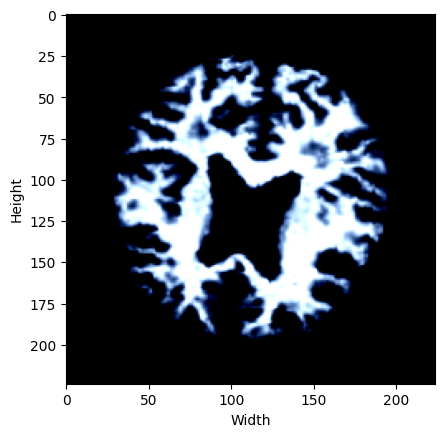

In [13]:
# Plotting 

plt.imshow(img)
plt.xlabel("Width")
plt.ylabel("Height")
plt.show()

In [14]:
train_datasets

Dataset ImageFolder
    Number of datapoints: 8756
    Root location: C:\Users\Admin\Desktop\Alzhiemers\Alzhiemer - MRI Scan\train
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )

In [15]:
len(train_loader)

274

In [16]:
len(train_datasets)

8756

In [17]:
# ResNet

model=models.resnet18(pretrained=True)
num_classes = 4

model.fc = nn.Linear(model.fc.in_features, num_classes)

c:\Users\Admin\ml2\envs\pytorch\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Admin\ml2\envs\pytorch\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [18]:
param=model.parameters()

In [19]:
# Loss Function And Cross Entropy

loss=torch.nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(params=param,lr=0.01)

In [20]:
# Accuracy 
def Accuracy(y_true,y_pred):
    acurate=(y_pred==y_true).sum().item()
    return (acurate/len(y_true))*100

In [21]:
import torch

epochs = 10

for epoch in range(epochs):
    
    # ==========================================
    # 1. TRAINING PHASE
    # ==========================================
    model.train()
    running_train_acc = 0.0
    running_train_loss = 0.0
    total_train_batches = 0
    
    for images, label in iter(train_loader):
        # Forward pass
        y_logit = model(images)
        Loss = loss(y_logit, label)
        
        # Backward pass
        optimizer.zero_grad()
        Loss.backward()
        optimizer.step()
        
        # Output handling
        label = label.to(torch.float32)
        y_prob = torch.softmax(y_logit, dim=1, dtype=torch.float32)
        y_pred = torch.argmax(y_prob, dim=1).to(torch.float32)
        
        # Accumulate metrics (using your Accuracy function)
        running_train_acc += Accuracy(y_pred, label) 
        running_train_loss += Loss.item()
        total_train_batches += 1
        
    # Calculate epoch averages
    epoch_train_acc = running_train_acc / total_train_batches
    epoch_train_loss = running_train_loss / total_train_batches

    # ==========================================
    # 2. TESTING / VALIDATION PHASE
    # ==========================================
    model.eval() 
    running_test_acc = 0.0
    running_test_loss = 0.0
    total_test_batches = 0

    with torch.no_grad(): 
        for images, label in iter(test_loader):
            # Forward pass
            y_logit = model(images)
            batch_loss = loss(y_logit, label)
            
            # Output handling
            label = label.to(torch.float32)
            y_prob = torch.softmax(y_logit, dim=1, dtype=torch.float32)
            y_pred = torch.argmax(y_prob, dim=1).to(torch.float32)
            
            # Accumulate metrics (using the exact same logic as training)
            running_test_acc += Accuracy(y_pred, label)
            running_test_loss += batch_loss.item()
            total_test_batches += 1

    # Calculate epoch averages
    epoch_test_acc = running_test_acc / total_test_batches
    epoch_test_loss = running_test_loss / total_test_batches

    # ==========================================
    # 3. PRINTING RESULTS
    # ==========================================
    if epoch % 2 == 0:
        print(f"--- Epoch {epoch} ---")
        print(f"Train Loss: {epoch_train_loss:.4f} | Train Accuracy: {epoch_train_acc:.2f}%")
        print(f"Test Loss:  {epoch_test_loss:.4f} | Test Accuracy:  {epoch_test_acc:.2f}%\n")

--- Epoch 0 ---
Train Loss: 1.1855 | Train Accuracy: 45.99%
Test Loss:  2.3296 | Test Accuracy:  20.12%

--- Epoch 2 ---
Train Loss: 0.7823 | Train Accuracy: 62.75%
Test Loss:  2.9456 | Test Accuracy:  35.29%

--- Epoch 4 ---
Train Loss: 0.5611 | Train Accuracy: 73.73%
Test Loss:  3.6447 | Test Accuracy:  29.65%

--- Epoch 6 ---
Train Loss: 0.4878 | Train Accuracy: 78.36%
Test Loss:  1.3945 | Test Accuracy:  55.41%

--- Epoch 8 ---
Train Loss: 0.2931 | Train Accuracy: 88.11%
Test Loss:  0.5550 | Test Accuracy:  79.80%



In [23]:
# Save only the learned weights
file_path=r"C:\Users\Admin\Desktop\Alzhiemers\alzheimers_resnet_weights.pth"
torch.save(model.state_dict(),file_path)
print("Model weights saved successfully!")

Model weights saved successfully!


In [25]:
def clean_image(pytorch_tensor):
    # This rips away the PyTorch formatting and fixes the colors
    img = pytorch_tensor.cpu().detach().permute(1, 2, 0).numpy()
    return (img - img.min()) / (img.max() - img.min())

In [ ]:


# Step 1: Setup the tool to look at the final layer of your ResNet
cam = HiResCAM(model=model, target_layers=[model.layer4[-1]])

# Step 2: Grab your image and clean it using our function above
my_image = images[0]
normal_picture = clean_image(my_image)

# Step 3: Generate the heatmap (Targeting Class 1: Moderate Demented)
heatmap = cam(input_tensor=my_image.unsqueeze(0), targets=[ClassifierOutputTarget(1)])[0, :]

# Step 4: Glue the heatmap on top of the normal picture
final_visual = show_cam_on_image(normal_picture, heatmap, use_rgb=True)

# Step 5: Save it straight to your desktop folder
save_path = r"C:\Users\Admin\Desktop\Alzhiemers\simple_heatmap.jpg"
cv2.imwrite(save_path, cv2.cvtColor(final_visual, cv2.COLOR_RGB2BGR))

# Pops open a window to show the image
cv2.imshow("HiResCAM Result", final_visual)
cv2.waitKey(0) # Keeps the window open until you press any key

In [ ]:


# 1. Load your ALREADY TRAINED model weights from your desktop
# (Assuming your 'model' variable is already set up as the ResNet skeleton)
weights_path = r"C:\Users\Admin\Desktop\Alzhiemers\alzheimers_resnet_weights.pth"
model.load_state_dict(torch.load(weights_path))

# CRITICAL: Put the loaded model into evaluation mode
model.eval() 

# 2. Run just the test set ONE time
all_labels = []
all_preds = []
all_probs = []


with torch.no_grad():
    for images, label in iter(test_loader):
        # Forward pass
        y_logit = model(images)
        
        # Output handling
        label = label.to(torch.float32)
        y_prob = torch.softmax(y_logit, dim=1, dtype=torch.float32)
        y_pred = torch.argmax(y_prob, dim=1).to(torch.float32)
        
        # Store for Scikit-Learn
        all_labels.extend(label.cpu().numpy())
        all_preds.extend(y_pred.cpu().numpy())
        all_probs.extend(y_prob.cpu().numpy())

# 3. Calculate and print your professional metrics
final_roc_auc = roc_auc_score(all_labels, all_probs, multi_class="ovr", average="macro")
final_recall = recall_score(all_labels, all_preds, zero_division=0, average="macro")
final_f1 = f1_score(all_labels, all_preds, zero_division=0, average="macro")

print("\n--- Final Evaluation Results ---")
print(f"Test ROC-AUC:  {final_roc_auc:.4f}")
print(f"Test Recall:   {final_recall:.4f}")
print(f"Test F1-Score: {final_f1:.4f}")

C:\Users\Admin\AppData\Local\Temp\ipykernel_19840\1489246037.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(weights_path))


Evaluating saved model... this should only take a moment.

--- Final Evaluation Results ---
Test ROC-AUC:  0.9746
Test Recall:   0.7528
Test F1-Score: 0.7733
